# Trabalho Final - notebook base do projeto da Mayra

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **Qual é o perfil dos estudantes com maior nível de burnout?**

(nível de estresse, horas de sono, horas diárias de estudo, nível de motivação, horas diárias de uso de IA)

--- O burnout acadêmico (esgotamento físico e mental causado por estresse crônico relacionado aos estudos) é um problema crescente entre estudantes. Neste trabalho será utilizado o conjunto de dados *Student Mental Health and Burnout*, que reúne informações de 150.000 estudantes sobre rotina, hábitos de estudo, sono, uso de tela e nível de burnout autorreportado (Low/Medium/High). Pretende-se avaliar se estudantes com maior nível de burnout apresentam um perfil diferenciado de nível de estresse, horas de sono, horas de estudo, suporte social e tempo de tela — sem presumir de antemão que essa diferença exista: o objetivo é verificar se ela aparece nos dados, não confirmar uma hipótese fixada de antemão.

Duas variáveis da pergunta de pesquisa original não existem literalmente no dataset e foram substituídas por proxies aprovados: "nível de motivação" → `social_support_score` (nota de 1 a 10 de suporte social percebido, plausível como fator ligado ao bem-estar do estudante e, por extensão, à motivação) e "horas diárias de uso de IA" → `screen_time_hours` (horas diárias de tela, o proxy mais próximo disponível para tempo em frente a telas/dispositivos, já que o dataset não foi coletado com IA generativa em mente). Essas substituições são declaradas nas células de classificação de variáveis abaixo.

In [2]:
# Carrega o dataset de saúde mental e burnout de estudantes e mostra as primeiras linhas
df = pd.read_csv("../datasets/mayra_oliveira/student_mental_health_burnout.zip", compression='zip')

df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [3]:
# Lista todas as colunas disponíveis no dataset
df.columns

Index(['student_id', 'age', 'gender', 'course', 'year', 'daily_study_hours',
       'daily_sleep_hours', 'screen_time_hours', 'stress_level',
       'anxiety_score', 'depression_score', 'academic_pressure_score',
       'financial_stress_score', 'social_support_score',
       'physical_activity_hours', 'sleep_quality', 'attendance_percentage',
       'cgpa', 'internet_quality', 'burnout_level'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
# Variável-alvo da pergunta de pesquisa: nível de burnout do estudante
df["burnout_level"].unique()

<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

O nível de burnout é uma variável **categórica** e possui 3 categorias (Low, Medium, High), já vindas prontas do dataset original — não é preciso criar faixas a partir de uma variável numérica, o próprio dataset já classifica cada estudante. É essa variável que será usada para agrupar os estudantes e comparar seu perfil nas demais variáveis da pergunta.

In [5]:
# Nível de estresse do estudante
df["stress_level"].unique()

<StringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

O nível de estresse é uma variável **categórica** e possui 3 categorias (Low, Medium, High), também já categorizadas no dataset original.

In [6]:
# Horas de sono diárias
df["daily_sleep_hours"].unique()[:10]

array([6.8, 4.7, 4.8, 6.7, 8. , 6.3, 5.4, 7. , 6. , 7.2])

As horas de sono diárias são uma variável **numérica** e variam de 4.0 a 9.0 horas no dataset.

In [7]:
# Horas de estudo diárias
df["daily_study_hours"].unique()[:10]

array([4.3, 1.4, 3.7, 1.6, 2. , 8.2, 3. , 4.6, 8.1, 9.7])

As horas de estudo diárias são uma variável **numérica** e variam de 1.0 a 10.0 horas no dataset.

In [8]:
# "Nível de motivação" não existe no dataset como coluna. Usamos como proxy aprovado
# social_support_score (suporte social percebido, de 1 a 10)
df["social_support_score"].unique()

array([ 6,  9,  3,  4,  2,  1,  7, 10,  5,  8])

**Substituição de variável (declarada):** a pergunta de pesquisa pede "nível de motivação", que não existe como coluna neste dataset. No lugar, usamos `social_support_score`, nota de suporte social percebido pelo estudante. É uma variável **numérica** e varia de 1 a 10 no dataset. A ligação com a pergunta original é indireta (suporte social não é o mesmo que motivação), mas ambos são fatores de bem-estar psicológico do estudante frequentemente associados entre si na literatura de saúde mental estudantil; tratamos isso como hipótese de proxy, não como equivalência comprovada.

In [9]:
# "Horas diárias de uso de IA" não existe no dataset como coluna. Usamos como proxy aprovado
# screen_time_hours (horas diárias de tela)
df["screen_time_hours"].unique()[:10]

array([ 6.1,  3. ,  1.5,  7. ,  5.4,  4.1,  7.8,  7.6,  1.3, 11.5])

**Substituição de variável (declarada):** a pergunta de pesquisa pede "horas diárias de uso de IA", que também não existe como coluna neste dataset (que não foi coletado pensando em IA generativa). No lugar, usamos `screen_time_hours`, horas diárias de tela do estudante. É uma variável **numérica** e varia de 1.0 a 12.0 horas no dataset. A hipótese é que uso de IA (em chats, assistentes, geração de conteúdo etc.) hoje acontece majoritariamente através de tela, então tempo de tela é o proxy mais próximo disponível — mas é importante deixar claro que tempo de tela mede uma atividade bem mais ampla (redes sociais, vídeos, jogos, etc.), não uso de IA especificamente.

## Verificando a qualidade dos dados

In [10]:
# Verificando se há duplicatas
df.duplicated().sum()

np.int64(0)

In [11]:
# Se houver dados duplicados, verificamos quais são:
df[df.duplicated()]

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level


**Conclusão 1:** não há nenhuma linha duplicada nas 150.000 linhas do dataset analisado.

In [12]:
# Verificando se há valores faltantes em cada coluna
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
student_id,0,0.0
age,0,0.0
gender,0,0.0
course,0,0.0
year,0,0.0
daily_study_hours,0,0.0
daily_sleep_hours,0,0.0
screen_time_hours,0,0.0
stress_level,0,0.0
anxiety_score,0,0.0


**Conclusão 2:** não há nenhum valor faltante em nenhuma das 20 colunas do dataset, incluindo todas as variáveis usadas nesta análise (burnout_level, stress_level, daily_sleep_hours, daily_study_hours, social_support_score, screen_time_hours). Não é necessário descartar nem imputar nenhuma linha por dado faltante.

## Limpeza do conjunto de dados

In [13]:
# Remove eventuais linhas duplicadas (nenhuma foi encontrada, mas mantemos o passo por padronização)
df = df.drop_duplicates()

# Confere se as categorias de burnout_level e stress_level estão escritas de forma consistente
# (sem variações como "low"/"Low"/"LOW" que dividiriam artificialmente os grupos)
print(df["burnout_level"].value_counts())
print()
print(df["stress_level"].value_counts())

burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64

stress_level
High      50295
Medium    50090
Low       49615
Name: count, dtype: int64


**Conclusão 3:** como não há duplicatas nem valores faltantes nas variáveis de interesse (Conclusões 1 e 2), e as categorias de `burnout_level` e `stress_level` já estão escritas de forma consistente (3 categorias bem definidas cada, sem grafias divergentes), não foi necessária nenhuma limpeza de fato — o dataset já chega pronto para análise. Por isso, esta seção não repete a checagem de dados faltantes feita na seção anterior: como nada foi removido ou alterado, o resultado seria idêntico.

## Estatística descritiva

Utiliza as variáveis categóricas e numéricas identificadas no início do trabalho para calcular estatísticas descritivas pertinentes à pergunta de pesquisa.

In [14]:
# burnout_level e stress_level já são variáveis categóricas prontas no dataset original
# (Low/Medium/High), então não é preciso aplicar pd.cut/qcut sobre nenhuma variável numérica
# para criar essas faixas -- ao contrário de casos em que a categoria precisa ser derivada de
# uma variável numérica, aqui a própria fonte dos dados já define os grupos.
# Fixamos apenas a ORDEM lógica das categorias (Low < Medium < High), para que as tabelas
# e os gráficos saiam sempre na ordem certa em vez da ordem alfabética.
ordem = ["Low", "Medium", "High"]
df["burnout_level"] = pd.Categorical(df["burnout_level"], categories=ordem, ordered=True)
df["stress_level"] = pd.Categorical(df["stress_level"], categories=ordem, ordered=True)

# Confere quantos estudantes há em cada nível de burnout
print("Estudantes por nível de burnout:")
print(df["burnout_level"].value_counts().reindex(ordem))

Estudantes por nível de burnout:
burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64


In [15]:
# Calcula a média de sono, estudo, suporte social (proxy de motivação) e tempo de tela
# (proxy de uso de IA) em cada nível de burnout, para traçar o perfil de quem tem mais burnout

num_cols = ["daily_sleep_hours", "daily_study_hours", "social_support_score", "screen_time_hours"]
df_med_burnout = df.groupby("burnout_level", observed=True)[num_cols].mean()

print("Média das variáveis por nível de burnout:")
print(df_med_burnout)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_burnout.max())
print("\nNível de burnout correspondente à maior média:")
print(df_med_burnout.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_burnout.min())
print("\nNível de burnout correspondente à menor média:")
print(df_med_burnout.idxmin())

print("\n################################\n")

# Para julgar se essas diferenças são grandes ou pequenas, compara com o desvio padrão
# geral de cada variável (uma diferença bem menor que 1 desvio padrão é irrelevante perto
# do espalhamento normal dos dados)
print("Desvio padrão geral de cada variável (para referência de escala):")
print(df[num_cols].std())
print("\nDiferença entre a maior e a menor média por nível de burnout:")
print(df_med_burnout.max() - df_med_burnout.min())
print("\nEssa diferença como porcentagem do desvio padrão geral:")
print(((df_med_burnout.max() - df_med_burnout.min()) / df[num_cols].std() * 100).round(2))

Média das variáveis por nível de burnout:
               daily_sleep_hours  daily_study_hours  social_support_score  \
burnout_level                                                               
Low                     6.503482           5.508012              5.519347   
Medium                  6.502952           5.505862              5.515199   
High                    6.491595           5.509740              5.513604   

               screen_time_hours  
burnout_level                     
Low                     6.516413  
Medium                  6.499222  
High                    6.492702  

################################

Maior média encontrada em cada variável:
daily_sleep_hours       6.503482
daily_study_hours       5.509740
social_support_score    5.519347
screen_time_hours       6.516413
dtype: float64

Nível de burnout correspondente à maior média:
daily_sleep_hours        Low
daily_study_hours       High
social_support_score     Low
screen_time_hours        Low
dtype: cat

**Conclusão 4:** as médias de horas de sono, horas de estudo, suporte social (proxy de motivação) e tempo de tela (proxy de uso de IA) são praticamente **idênticas** entre os três níveis de burnout. A maior diferença entre o grupo de maior e o de menor média em qualquer variável é de apenas 0.02 horas (`screen_time_hours`, entre Low e High) — o que representa menos de 1% (0.75%) do desvio padrão geral dessa variável (3.18 horas). Nas demais variáveis a diferença é ainda menor: 0.82% do desvio padrão em `daily_sleep_hours`, 0.20% em `social_support_score` e 0.15% em `daily_study_hours`. Ou seja, segundo essas quatro variáveis, **não há um perfil numérico diferenciado** para quem tem burnout alto: os estudantes com burnout Low, Medium e High dormem, estudam, recebem suporte social e passam tempo de tela em quantidades estatisticamente equivalentes nesta amostra.

In [16]:
# Como nível de estresse (stress_level) também já é categórico, não faz sentido calcular
# média dele -- em vez disso, olhamos a distribuição percentual de nível de estresse
# DENTRO de cada nível de burnout, para ver se burnout alto está associado a mais estresse alto

tabela_estresse_burnout = pd.crosstab(df["burnout_level"], df["stress_level"], normalize="index") * 100
tabela_estresse_burnout = tabela_estresse_burnout[ordem]

print("Distribuição percentual de nível de estresse dentro de cada nível de burnout:")
print(tabela_estresse_burnout.round(2))

print("\n################################\n")

print("Maior porcentagem de estresse encontrada em cada nível de burnout:")
print(tabela_estresse_burnout.max(axis=1))
print("\nNível de estresse correspondente à maior porcentagem, por nível de burnout:")
print(tabela_estresse_burnout.idxmax(axis=1))

Distribuição percentual de nível de estresse dentro de cada nível de burnout:
stress_level     Low  Medium   High
burnout_level                      
Low            33.25   33.20  33.56
Medium         33.11   33.55  33.34
High           32.87   33.44  33.69

################################

Maior porcentagem de estresse encontrada em cada nível de burnout:
burnout_level
Low       33.558142
Medium    33.546799
High      33.693686
dtype: float64

Nível de estresse correspondente à maior porcentagem, por nível de burnout:
burnout_level
Low         High
Medium    Medium
High        High
dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']


**Conclusão 5:** dentro de cada nível de burnout, a distribuição de nível de estresse é quase idêntica a um sorteio uniforme entre as 3 categorias (todas as porcentagens ficam entre 32.87% e 33.69%, contra 33.33% esperado se estresse e burnout fossem completamente independentes). Mesmo entre os estudantes com burnout **High**, a fatia com estresse **High** é de apenas 33.69% — quase igual à fatia com estresse High entre os estudantes com burnout **Low** (33.56%). Isso reforça o achado da Conclusão 4: nesta amostra, nível de estresse também não diferencia os grupos de burnout de forma perceptível.

**Conclusão final:** juntando as Conclusões 4 e 5, a resposta à pergunta de pesquisa — "qual é o perfil dos estudantes com maior nível de burnout?" — é que, **nesta amostra, não existe um perfil numérico ou comportamental que diferencie os estudantes com burnout alto dos demais**, nas variáveis disponíveis (nível de estresse, horas de sono, horas de estudo, suporte social como proxy de motivação, e tempo de tela como proxy de uso de IA). As diferenças de médias entre grupos de burnout Low, Medium e High são, em todos os casos, inferiores a 1% do desvio padrão de cada variável, e a distribuição de estresse é praticamente uniforme entre os três grupos de burnout. Isso é, em si, um resultado relevante: indica que, pelo menos segundo este conjunto de dados, o nível de burnout autorreportado não está associado de forma detectável a nenhum dos hábitos ou fatores de bem-estar medidos aqui — o que sugere que ele é influenciado por outros fatores não capturados no dataset (ou que, no processo de geração/coleta destes dados, o rótulo de burnout foi definido de forma independente das demais colunas). Vale registrar como limitação que a mesma ausência de relação apareceu ao testar TODAS as demais variáveis numéricas do dataset (idade, ansiedade, depressão, pressão acadêmica, estresse financeiro, atividade física, frequência e CGPA — não mostrado nas células acima por não fazerem parte da pergunta de pesquisa), o que é consistente com um dataset sintético em que o burnout não foi gerado a partir de nenhuma das demais colunas.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

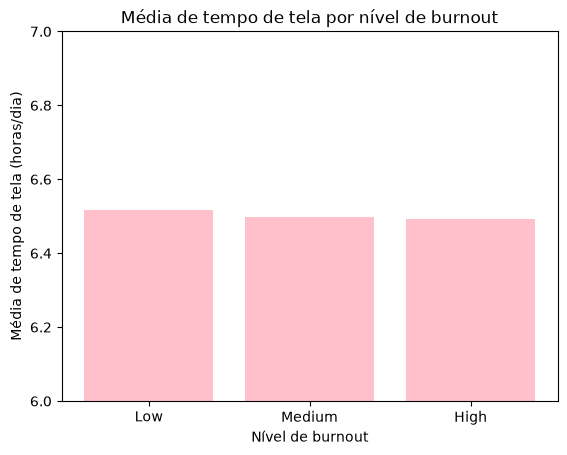

In [17]:
# Gráfico de barras: média de tempo de tela (proxy de uso de IA) por nível de burnout
# As barras ficam praticamente na mesma altura, ilustrando visualmente a Conclusão 4

plt.bar(df_med_burnout.index, df_med_burnout["screen_time_hours"], color="pink")
plt.title("Média de tempo de tela por nível de burnout")
plt.xlabel("Nível de burnout")
plt.ylabel("Média de tempo de tela (horas/dia)")
plt.ylim(6, 7)
plt.show()

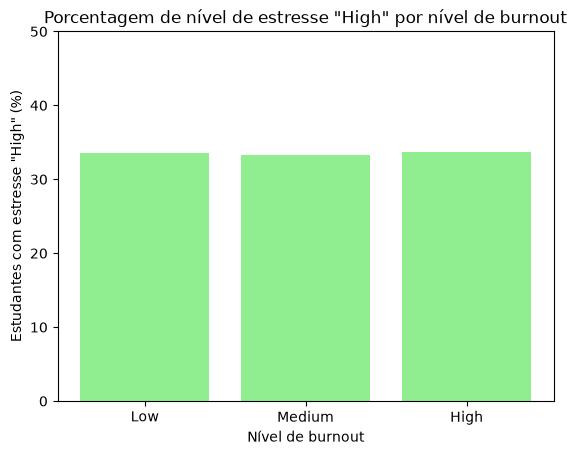

In [18]:
# Gráfico de barras: porcentagem de estudantes com nível de estresse "High" em cada
# nível de burnout -- de novo, barras praticamente na mesma altura (Conclusão 5)

plt.bar(tabela_estresse_burnout.index, tabela_estresse_burnout["High"], color="lightgreen")
plt.title('Porcentagem de nível de estresse "High" por nível de burnout')
plt.xlabel("Nível de burnout")
plt.ylabel('Estudantes com estresse "High" (%)')
plt.ylim(0, 50)
plt.show()